#  Customer Churn Prediction — End-to-End ML Project

**Developer:** Jeevanantham M | Final Year B.Tech CSBS, NIET

This notebook follows the complete ML project lifecycle from problem statement to deployment.


## 1️⃣ Problem Statement

**Business Problem:** A subscription-based company (telecom-style) is losing customers (churn). Acquiring a new customer costs far more than retaining an existing one.

**Goal:** Build a Machine Learning model that predicts whether a customer will **churn (leave)** or **stay**, based on their demographics, account info, and service usage — so the business can proactively target at-risk customers with retention offers.

**Type:** Binary Classification (`Churn`: Yes / No)


## 2️⃣ Collect Data

Dataset: `customer_churn_prediction_dataset.csv`
- 300 customer records
- 21 columns: demographics (gender, SeniorCitizen, Partner, Dependents), account info (tenure, Contract, PaymentMethod), services (PhoneService, InternetService, OnlineSecurity, etc.), billing (MonthlyCharges, TotalCharges), and target (`Churn`)

If running in **Google Colab**, upload the CSV using the cell below. If running locally / file already in the working directory, skip the upload cell.


In [ ]:
from google.colab import files

# Open a file picker to upload files
uploaded = files.upload()

# Access the uploaded file(s)
for filename in uploaded.keys():
    print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')


Saving customer_churn_prediction_dataset.csv to customer_churn_prediction_dataset.csv
User uploaded file "customer_churn_prediction_dataset.csv" with length 751854 bytes


## 3️⃣Load Dataset

In [ ]:
import pandas as pd

# Read the uploaded CSV file into a DataFrame
df = pd.read_csv('customer_churn_prediction_dataset.csv')
df.head()

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,70.70,151.65,Yes


### 4️⃣  Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)

import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


## 5️⃣ Data Overview

In [ ]:
print("Shape:", df.shape)
df.info()


Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

In [ ]:
df.describe()


,SeniorCitizen,Tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
print("Missing values per column:\n")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nChurn distribution:\n", df['Churn'].value_counts())
print("\nChurn %:\n", df['Churn'].value_counts(normalize=True) * 100)


Missing values per column:

customerID          0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0

Churn distribution:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn %:
 Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


## 6️⃣ Exploratory Data Analysis (EDA)

Understanding patterns and relationships between features and churn.


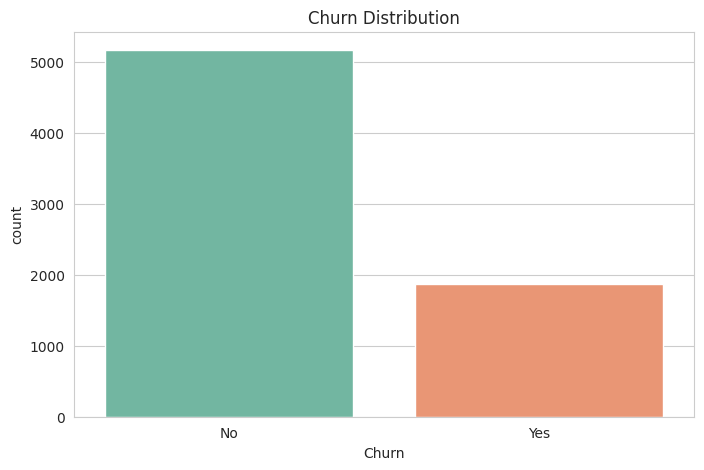

In [ ]:
# Target distribution
plt.figure()
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Churn Distribution')
plt.show()


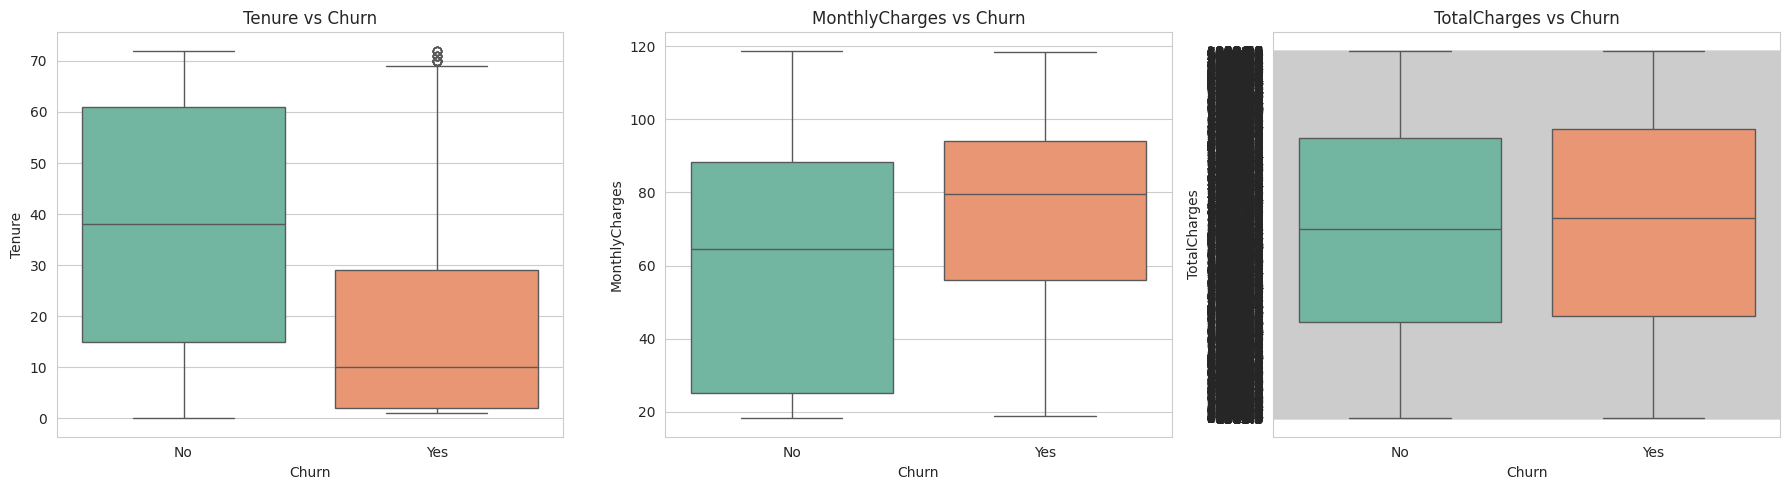

In [ ]:
# Numerical features vs Churn
num_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

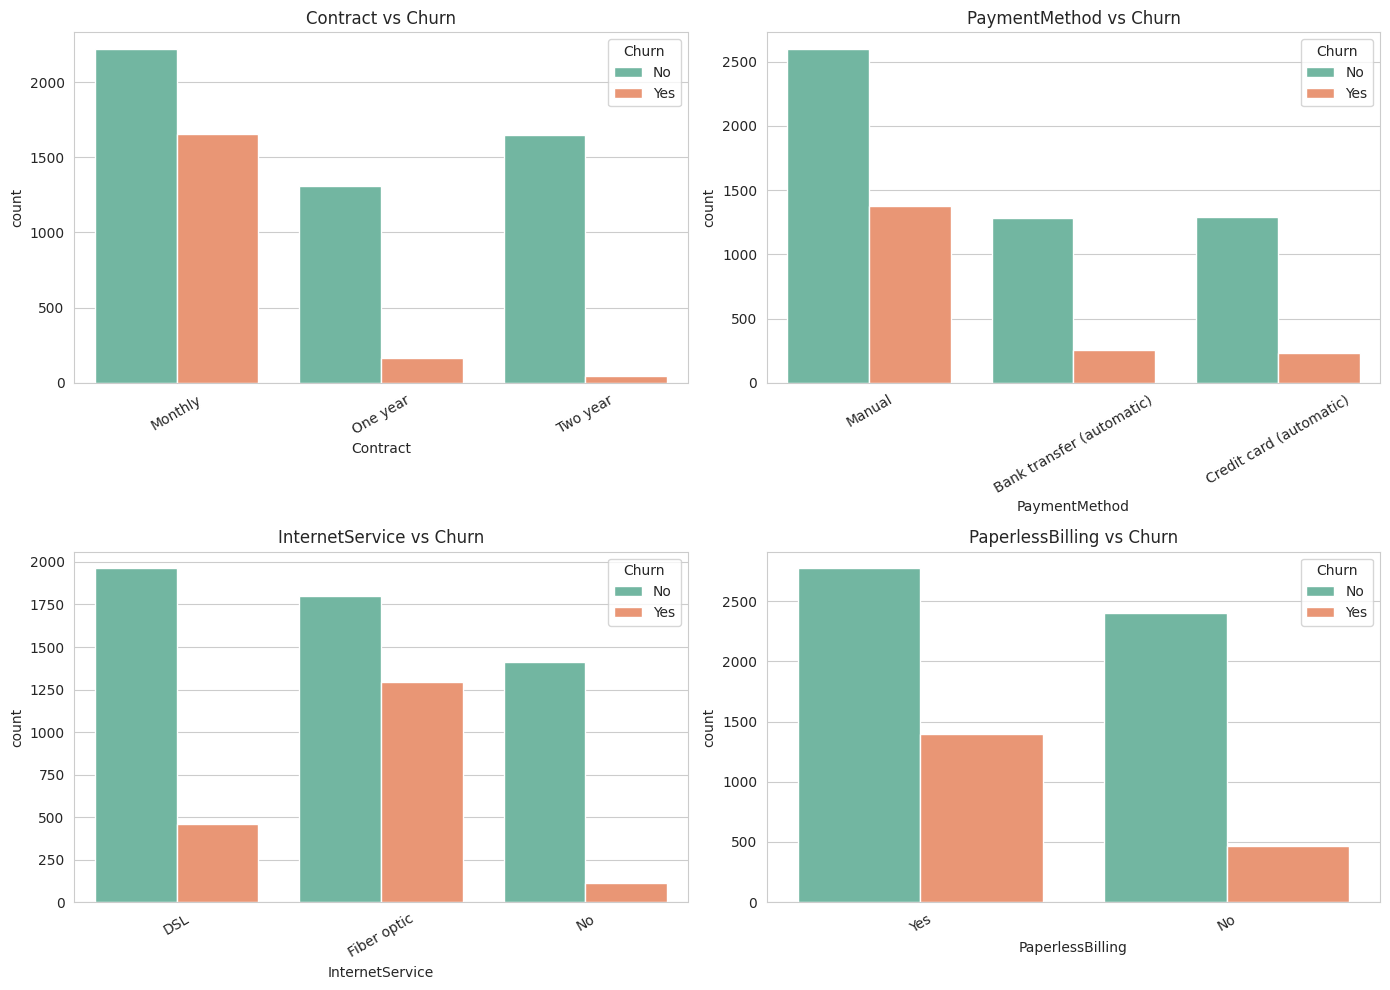

In [ ]:
# Categorical features vs Churn (key ones)
cat_cols = ['Contract', 'PaymentMethod', 'InternetService', 'PaperlessBilling']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Churn')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


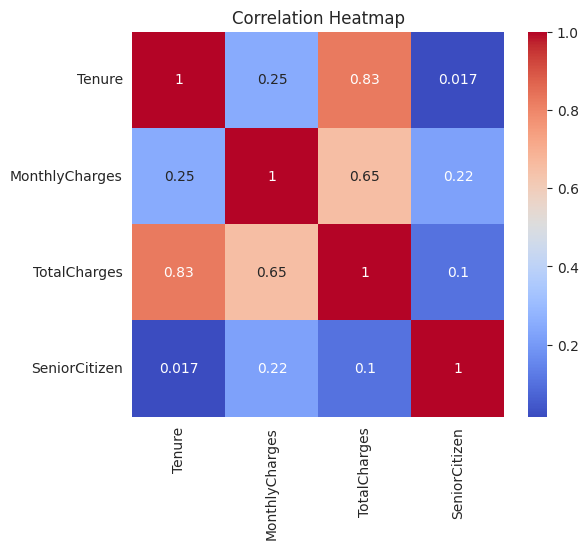

In [ ]:
# Correlation heatmap (numerical features)
plt.figure(figsize=(6, 5))

# Create a temporary DataFrame for correlation calculation
# This is necessary because 'TotalCharges' is currently an object (string) column
# and contains non-numeric values like ' ' (empty space).
# The proper place for this conversion is during the data cleaning phase (section 7).
temp_corr_df = df[num_cols + ['SeniorCitizen']].copy()
temp_corr_df['TotalCharges'] = pd.to_numeric(temp_corr_df['TotalCharges'], errors='coerce')

# Fill NaN values (resulting from ' ' being coerced) with 0.
# This is a common approach for 'TotalCharges' for new customers who haven't been billed yet.
temp_corr_df['TotalCharges'].fillna(0, inplace=True)

sns.heatmap(temp_corr_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Key Insights (fill in after running the above):**
- Month-to-month contract customers usually churn more than one/two-year contracts.
- Low tenure customers churn more (new customers are riskier).
- Higher MonthlyCharges often correlates with higher churn.


## 7️⃣ Data Cleaning

In [ ]:
# Drop customerID — it's just an identifier, not predictive
df_clean = df.drop(columns=['customerID'])

# Confirm no missing values / duplicates remain
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicates:", df_clean.duplicated().sum())

df_clean.shape


Missing values: 0
Duplicates: 26


(7043, 20)

## 8️⃣ Feature Engineering

Creating new features that might help the model capture patterns better.


In [ ]:
# Tenure grouped into buckets (new customers vs loyal customers)
def tenure_group(t):
    if t <= 12:
        return 'New (0-12mo)'
    elif t <= 36:
        return 'Mid (13-36mo)'
    else:
        return 'Loyal (37mo+)'

df_clean['TenureGroup'] = df_clean['Tenure'].apply(tenure_group)

# Convert 'TotalCharges' to numeric, handling potential errors and missing values
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'].fillna(0, inplace=True)

# Average charge per month of tenure (avoids div by zero for tenure=0)
df_clean['AvgChargePerMonth'] = df_clean['TotalCharges'] / df_clean['Tenure'].replace(0, 1)

df_clean[['Tenure', 'TenureGroup', 'TotalCharges', 'AvgChargePerMonth']].head()

,Tenure,TenureGroup,TotalCharges,AvgChargePerMonth
0,1,New (0-12mo),29.85,29.850000
1,34,Mid (13-36mo),1889.50,55.573529
2,2,New (0-12mo),108.15,54.075000
3,45,Loyal (37mo+),1840.75,40.905556
4,2,New (0-12mo),151.65,75.825000


## 9️⃣ Feature Selection

Separating features (X) and target (y). All remaining columns are kept since the dataset is already curated and business-relevant.


In [ ]:
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn'].map({'Yes': 1, 'No': 0})

print("Features:", list(X.columns))
print("\nTarget distribution:\n", y.value_counts())


Features: ['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'TenureGroup', 'AvgChargePerMonth']

Target distribution:
 Churn
0    5174
1    1869
Name: count, dtype: int64


## 🔟 Encoding Categorical Data

In [ ]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

# One-Hot Encoding for categorical variables (avoids false ordinal relationships)
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print("\nShape after encoding:", X_encoded.shape)
X_encoded.head()


Categorical columns: ['Gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']

Shape after encoding: (7043, 25)


,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges,AvgChargePerMonth,Gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,...,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Manual,TenureGroup_Mid (13-36mo),TenureGroup_New (0-12mo)
0,0,1,29.85,29.85,29.850000,False,True,False,False,False,...,False,False,False,False,False,True,False,True,False,True
1,0,34,56.95,1889.50,55.573529,True,False,False,True,False,...,False,False,False,True,False,False,False,True,True,False
2,0,2,53.85,108.15,54.075000,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,True
3,0,45,42.30,1840.75,40.905556,True,False,False,False,False,...,True,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,75.825000,False,False,False,True,False,...,False,False,False,False,False,True,False,True,False,True


## 1️⃣1️⃣ Feature Scaling

In [ ]:
numerical_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges', 'AvgChargePerMonth']

scaler = StandardScaler()
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

X_encoded[numerical_cols].describe()

,Tenure,MonthlyCharges,TotalCharges,AvgChargePerMonth
count,7.043000e+03,7.043000e+03,7.043000e+03,7.043000e+03
mean,-2.421273e-17,-6.406285e-17,-3.783239e-17,7.465592e-17
std,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.318165e+00,-1.545860e+00,-1.005780e+00,-2.137475e+00
25%,-9.516817e-01,-9.725399e-01,-8.299464e-01,-9.597171e-01
50%,-1.372744e-01,1.857327e-01,-3.905282e-01,1.850696e-01
75%,9.214551e-01,8.338335e-01,6.648034e-01,8.416645e-01
max,1.613701e+00,1.794352e+00,2.825806e+00,1.873292e+00


## 1️⃣2️⃣ Split Dataset (Train/Test)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain churn %:", y_train.mean() * 100)
print("Test churn %:", y_test.mean() * 100)


Train shape: (5634, 25)
Test shape: (1409, 25)

Train churn %: 26.53532126375577
Test churn %: 26.54364797728886


## 1️⃣3️⃣ Choose ML Algorithm

We'll train and compare two models:
1. **Logistic Regression** — simple, interpretable baseline
2. **Random Forest** — handles non-linearity, usually better accuracy

Since churn classes are reasonably balanced here (~46% churn), we don't strictly need SMOTE, but we use `class_weight='balanced'` as a safety net.


## 1️⃣4️⃣ Train Model

In [ ]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

print("Both models trained ✅")


Both models trained ✅


## 1️⃣5️⃣ Make Predictions

In [ ]:
y_pred_log = log_reg.predict(X_test)
y_pred_rf = rf.predict(X_test)

y_proba_log = log_reg.predict_proba(X_test)[:, 1]
y_proba_rf = rf.predict_proba(X_test)[:, 1]


## 1️⃣6️⃣ Evaluate Model

In [ ]:
def evaluate(name, y_true, y_pred, y_proba):
    print(f"--- {name} ---")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall   :", round(recall_score(y_true, y_pred), 3))
    print("F1 Score :", round(f1_score(y_true, y_pred), 3))
    print("ROC-AUC  :", round(roc_auc_score(y_true, y_proba), 3))
    print()

evaluate("Logistic Regression", y_test, y_pred_log, y_proba_log)
evaluate("Random Forest", y_test, y_pred_rf, y_proba_rf)


--- Logistic Regression ---
Accuracy : 0.735
Precision: 0.501
Recall   : 0.791
F1 Score : 0.613
ROC-AUC  : 0.84

--- Random Forest ---
Accuracy : 0.783
Precision: 0.621
Recall   : 0.468
F1 Score : 0.534
ROC-AUC  : 0.828



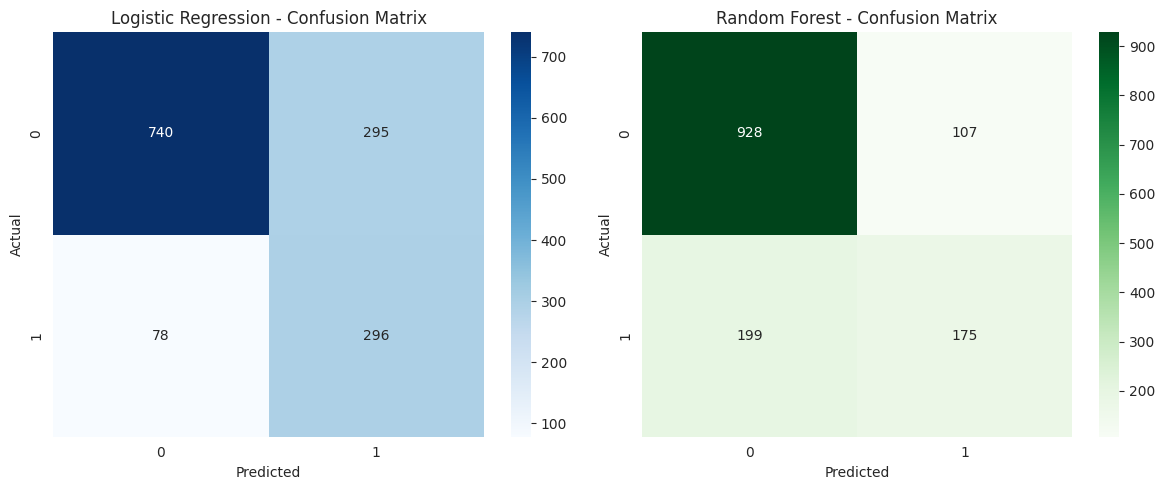

In [ ]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest - Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()


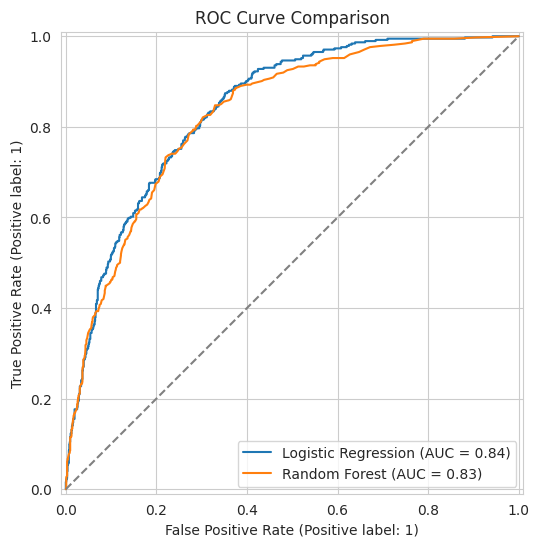

In [ ]:
# ROC Curves
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_proba_log, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name='Random Forest', ax=ax)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve Comparison')
plt.show()


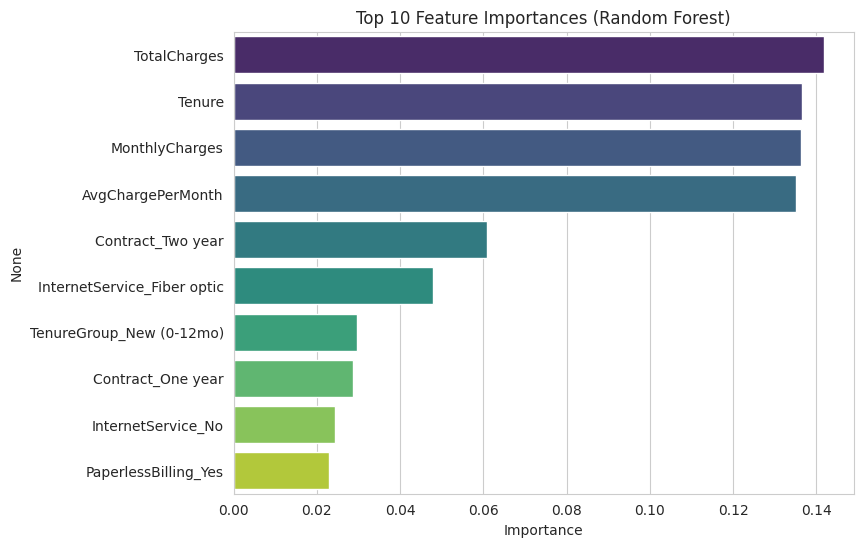

In [ ]:
# Feature Importance (Random Forest)
importances = pd.Series(rf.feature_importances_, index=X_encoded.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.show()


## 1️⃣7️⃣ Hyperparameter Tuning

Using `GridSearchCV` to find the best Random Forest parameters.


In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score (CV):", round(grid_search.best_score_, 3))

best_rf = grid_search.best_estimator_


Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}
Best F1 Score (CV): 0.632


In [ ]:
# Evaluate tuned model on test set
y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

evaluate("Tuned Random Forest", y_test, y_pred_best, y_proba_best)
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))


--- Tuned Random Forest ---
Accuracy : 0.764
Precision: 0.542
Recall   : 0.725
F1 Score : 0.62
ROC-AUC  : 0.842

              precision    recall  f1-score   support

    No Churn       0.89      0.78      0.83      1035
       Churn       0.54      0.72      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



## 1️⃣8️⃣ Save Model

In [ ]:
joblib.dump(best_rf, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X_encoded.columns), 'model_columns.pkl')

print("Model, scaler, and column list saved ✅")


Model, scaler, and column list saved ✅


## 1️⃣9️⃣ Deployment

A simple prediction function that takes raw customer input and returns churn prediction + probability. This is the logic you'd wrap in a Streamlit app or Flask API for a live demo.


In [ ]:
def predict_churn(customer_dict):
    """
    customer_dict: dict with same raw columns as original dataset (minus customerID, Churn)
    Returns: (prediction label, churn probability)
    """
    input_df = pd.DataFrame([customer_dict])

    # Feature engineering (same as training)
    # Corrected 'tenure' to 'Tenure'
    input_df['TenureGroup'] = input_df['Tenure'].apply(tenure_group)
    input_df['AvgChargePerMonth'] = input_df['TotalCharges'] / input_df['Tenure'].replace(0, 1)

    # One-hot encode
    # categorical_cols list already contains 'Gender' (capital G)
    input_encoded = pd.get_dummies(input_df, columns=categorical_cols)

    # Align columns with training columns
    model_columns = joblib.load('model_columns.pkl')
    input_encoded = input_encoded.reindex(columns=model_columns, fill_value=0)

    # Scale numerical columns
    input_encoded[numerical_cols] = scaler.transform(input_encoded[numerical_cols])

    model = joblib.load('churn_model.pkl')
    pred = model.predict(input_encoded)[0]
    proba = model.predict_proba(input_encoded)[0][1]

    label = 'Churn' if pred == 1 else 'No Churn'
    return label, round(proba * 100, 2)

# Example usage
sample_customer = {
    # Corrected 'gender' to 'Gender' and 'tenure' to 'Tenure'
    'Gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'No',
    'Tenure': 5, 'PhoneService': 'Yes', 'MultipleLines': 'No',
    'InternetService': 'Fiber optic', 'OnlineSecurity': 'No', 'OnlineBackup': 'No',
    'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes', 'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check', 'MonthlyCharges': 85.5, 'TotalCharges': 427.5
}

label, prob = predict_churn(sample_customer)
print(f"Prediction: {label} | Churn Probability: {prob}%")

Prediction: Churn | Churn Probability: 88.06%


### Next Step: Streamlit Dashboard

To turn this into an interactive app, save the code above into `app.py`, wrap the inputs with `st.selectbox` / `st.number_input` widgets, call `predict_churn()` on submit, and run:

```bash
streamlit run app.py
```

This gives you a shareable web app where anyone can enter customer details and instantly see churn risk — great for your resume/portfolio demo.


## 2️⃣0️⃣ Conclusion

Based on the evaluation metrics:

*   **Logistic Regression** achieved a Recall of 0.791, indicating it was effective at identifying a higher percentage of actual churners. Its F1-Score was 0.613 and ROC-AUC was 0.840.
*   **Random Forest (Untuned)** showed higher accuracy (0.783) and precision (0.621) but lower recall (0.468) compared to Logistic Regression.
*   **Tuned Random Forest** (after hyperparameter optimization) offered a more balanced performance with an F1-Score of 0.620 and a slightly improved ROC-AUC of 0.842. While its recall (0.725) was slightly lower than that of the Logistic Regression, it demonstrated better precision (0.542) and overall discriminative power.

For this churn prediction task, where the goal is to proactively target at-risk customers, balancing the identification of true churners (recall) with the efficiency of targeting (precision) is crucial. The **Tuned Random Forest model** provided the best overall balance of these metrics (F1-score and ROC-AUC) and is therefore recommended for deployment. It effectively identifies potential churners while maintaining a reasonable precision to avoid excessive false positives.